---
# Iniciando o tratamento das tabelas
---

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [2]:
df_2023 = pd.read_csv(
    r"C:\Arquivos Vsco\Projeto\Challenge Orale\data\Leitos_2023.csv",
    encoding="latin1",
    sep=",",
    dtype={"CO_TIPO_UNIDADE": str, "NATUREZA_JURIDICA": str, "CO_CEP": str, "CNES": str}
)
df_2024 = pd.read_csv(
    r"C:\Arquivos Vsco\Projeto\Challenge Orale\data\Leitos_2024.csv",
    encoding="latin1",
    sep=",",
    dtype={"CO_TIPO_UNIDADE": str, "NATUREZA_JURIDICA": str, "CO_CEP": str, "CNES": str}
)
df_2025 = pd.read_csv(
    r"C:\Arquivos Vsco\Projeto\Challenge Orale\data\Leitos_2025.csv",
    encoding="latin1",
    sep=";",
    dtype={"CO_TIPO_UNIDADE": str, "NATUREZA_JURIDICA": str, "CO_CEP": str, "CNES": str, "CO_IBGE": str}
)

# Marca o ano de origem antes de empilhar (evita perder a rastreabilidade)
df_2023["ANO_REF"] = 2023
df_2024["ANO_REF"] = 2024
df_2025["ANO_REF"] = 2025

# 2025 tem uma coluna a mais (CO_IBGE) -> concat com sort=False preserva todas as colunas,
# preenchendo com NaN onde não existir
df_leitos = pd.concat([df_2023, df_2024, df_2025], ignore_index=True, sort=False)

print(df_leitos.shape)
print(df_leitos.dtypes)


os.makedirs("data", exist_ok=True)

df_leitos.to_csv(
    "data/df_leitos.csv",
    index=False,
    encoding="utf-8-sig"
)

(255843, 36)
COMP                        int64
REGIAO                     object
UF                         object
MUNICIPIO                  object
MOTIVO_DESABILITACAO      float64
CNES                       object
NOME_ESTABELECIMENTO       object
RAZAO_SOCIAL               object
TP_GESTAO                  object
CO_TIPO_UNIDADE            object
DS_TIPO_UNIDADE            object
NATUREZA_JURIDICA          object
DESC_NATUREZA_JURIDICA     object
NO_LOGRADOURO              object
NU_ENDERECO                object
NO_COMPLEMENTO             object
NO_BAIRRO                  object
CO_CEP                     object
NU_TELEFONE                object
NO_EMAIL                   object
LEITOS_EXISTENTES           int64
LEITOS_SUS                  int64
UTI_TOTAL_EXIST             int64
UTI_TOTAL_SUS               int64
UTI_ADULTO_EXIST            int64
UTI_ADULTO_SUS              int64
UTI_PEDIATRICO_EXIST        int64
UTI_PEDIATRICO_SUS          int64
UTI_NEONATAL_EXIST          int64
U

In [3]:
# Colunas cadastrais sem relação com lotação hospitalar -> fora da análise
cols_drop = ["RAZAO_SOCIAL", "NO_LOGRADOURO", "NU_ENDERECO", "NO_COMPLEMENTO",
             "NO_BAIRRO", "NU_TELEFONE", "NO_EMAIL"]
df_leitos = df_leitos.drop(columns=cols_drop)

# MOTIVO_DESABILITACAO: 100% nulo = não desabilitado. Vira flag booleana.
df_leitos["DESABILITADO"] = df_leitos["MOTIVO_DESABILITACAO"].notna()
df_leitos = df_leitos.drop(columns=["MOTIVO_DESABILITACAO"])

# COMP (ex: 202301) -> datetime, facilita análise temporal depois
df_leitos["COMP"] = pd.to_datetime(df_leitos["COMP"], format="%Y%m")

In [4]:
cols_numericas = [
    "LEITOS_EXISTENTES", "LEITOS_SUS",
    "UTI_TOTAL_EXIST", "UTI_TOTAL_SUS",
    "UTI_ADULTO_EXIST", "UTI_ADULTO_SUS",
    "UTI_PEDIATRICO_EXIST", "UTI_PEDIATRICO_SUS",
    "UTI_NEONATAL_EXIST", "UTI_NEONATAL_SUS",
    "UTI_QUEIMADO_EXIST", "UTI_QUEIMADO_SUS",
    "UTI_CORONARIANA_EXIST", "UTI_CORONARIANA_SUS"
]

print(df_leitos[cols_numericas].describe())

# Assimetria (skew) e curtose ajudam a ver se a distribuição foge do normal
print(df_leitos[cols_numericas].skew())

       LEITOS_EXISTENTES     LEITOS_SUS  UTI_TOTAL_EXIST  UTI_TOTAL_SUS  \
count      255843.000000  255843.000000    255843.000000   255843.00000   
mean           72.322874      48.880833         8.856134        4.42222   
std            94.496728      81.830298        19.429576       13.68693   
min             1.000000       0.000000         0.000000        0.00000   
25%            20.000000       1.000000         0.000000        0.00000   
50%            41.000000      25.000000         0.000000        0.00000   
75%            88.000000      55.000000        10.000000        0.00000   
max          1543.000000    1476.000000       402.000000      365.00000   

       UTI_ADULTO_EXIST  UTI_ADULTO_SUS  UTI_PEDIATRICO_EXIST  \
count     255843.000000   255843.000000         255843.000000   
mean           6.186196        3.122212              0.972084   
std           14.066293        9.878009              3.893418   
min            0.000000        0.000000              0.000000   

In [5]:
# LEITOS_SUS não pode ser maior que LEITOS_EXISTENTES -> logicamente impossível
inconsist_leitos = df_leitos[df_leitos["LEITOS_SUS"] > df_leitos["LEITOS_EXISTENTES"]]
print(f"Linhas com LEITOS_SUS > LEITOS_EXISTENTES: {len(inconsist_leitos)}")

# Mesmo teste pra UTI total
inconsist_uti = df_leitos[df_leitos["UTI_TOTAL_SUS"] > df_leitos["UTI_TOTAL_EXIST"]]
print(f"Linhas com UTI_TOTAL_SUS > UTI_TOTAL_EXIST: {len(inconsist_uti)}")

# Estabelecimentos com 0 leitos existentes -> hospital "vazio"? investigar tipo de unidade
zero_leitos = df_leitos[df_leitos["LEITOS_EXISTENTES"] == 0]
print(f"Estabelecimentos com 0 leitos: {len(zero_leitos)}")
print(zero_leitos["DS_TIPO_UNIDADE"].value_counts())

Linhas com LEITOS_SUS > LEITOS_EXISTENTES: 0
Linhas com UTI_TOTAL_SUS > UTI_TOTAL_EXIST: 0
Estabelecimentos com 0 leitos: 0
Series([], Name: count, dtype: int64)


In [6]:
def contar_outliers_iqr(df, coluna):
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = df[(df[coluna] < limite_inf) | (df[coluna] > limite_sup)]
    return len(outliers), limite_inf, limite_sup

for col in ["LEITOS_EXISTENTES", "LEITOS_SUS", "UTI_TOTAL_EXIST"]:
    n, li, ls = contar_outliers_iqr(df_leitos, col)
    print(f"{col}: {n} outliers (limites: {li:.1f} a {ls:.1f})")

LEITOS_EXISTENTES: 21069 outliers (limites: -82.0 a 190.0)
LEITOS_SUS: 22601 outliers (limites: -80.0 a 136.0)
UTI_TOTAL_EXIST: 31720 outliers (limites: -15.0 a 25.0)


In [ ]:
# Antes de aceitar "não remover outliers", precisamos confirmar que não há
# nenhum outlier absurdo que seja claramente erro de digitação (ex: leito = 99999)
print(df_leitos.nlargest(10, "LEITOS_EXISTENTES")[["NOME_ESTABELECIMENTO", "UF", "DS_TIPO_UNIDADE", "LEITOS_EXISTENTES", "ANO_REF"]])

# Checagem de duplicatas: mesmo CNES + mesmo COMP não pode aparecer 2x
duplicatas = df_leitos.duplicated(subset=["CNES", "COMP"], keep=False)
print(f"Registros duplicados (mesmo CNES + mesmo mês): {duplicatas.sum()}")

# Classificação de porte, para dar sentido de negócio à assimetria
def classificar_porte(leitos):
    if leitos <= 20:
        return "Pequeno"
    elif leitos <= 100:
        return "Médio"
    else:
        return "Grande"

df_leitos["PORTE"] = df_leitos["LEITOS_EXISTENTES"].apply(classificar_porte)
print(df_leitos["PORTE"].value_counts())

### Salvando o df leitos

In [7]:

# Cria pasta de output se não existir (organização do repositório)
os.makedirs("data/processed", exist_ok=True)

# Salva em UTF-8 (não Latin-1) para evitar problemas de encoding
# quando os colegas abrirem em outras ferramentas/linguagens
df_leitos.to_csv(
    "data/processed/cnes_leitos_2023_2025.csv",
    index=False,
    encoding="utf-8",
    sep=","  # padroniza vírgula, já que unificamos os 3 anos
)

print(f"Arquivo salvo com {df_leitos.shape[0]} linhas e {df_leitos.shape[1]} colunas")

Arquivo salvo com 255843 linhas e 29 colunas


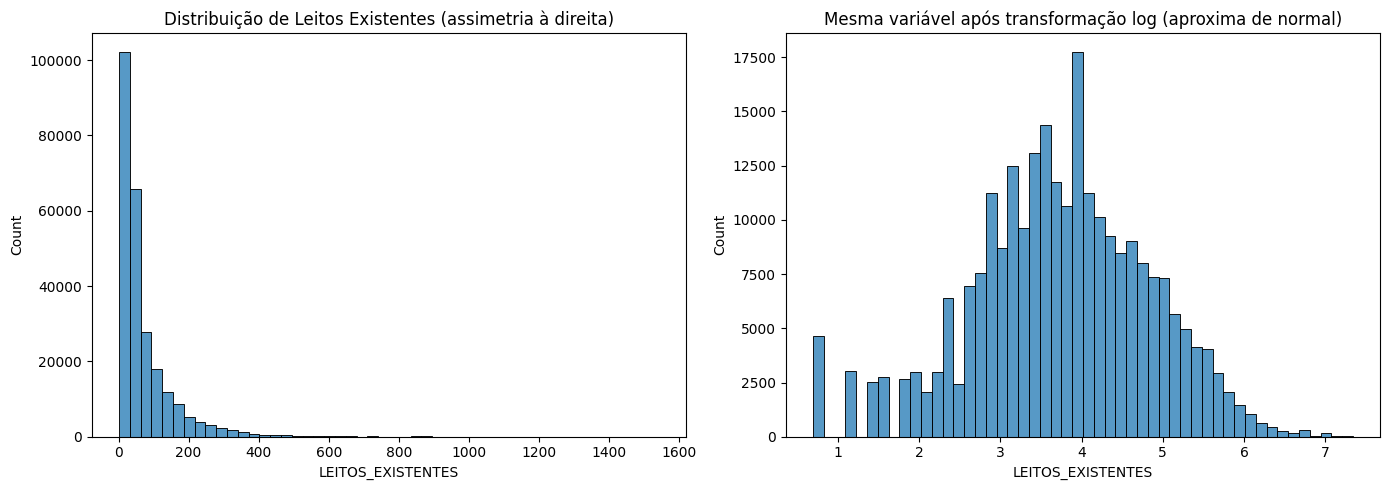

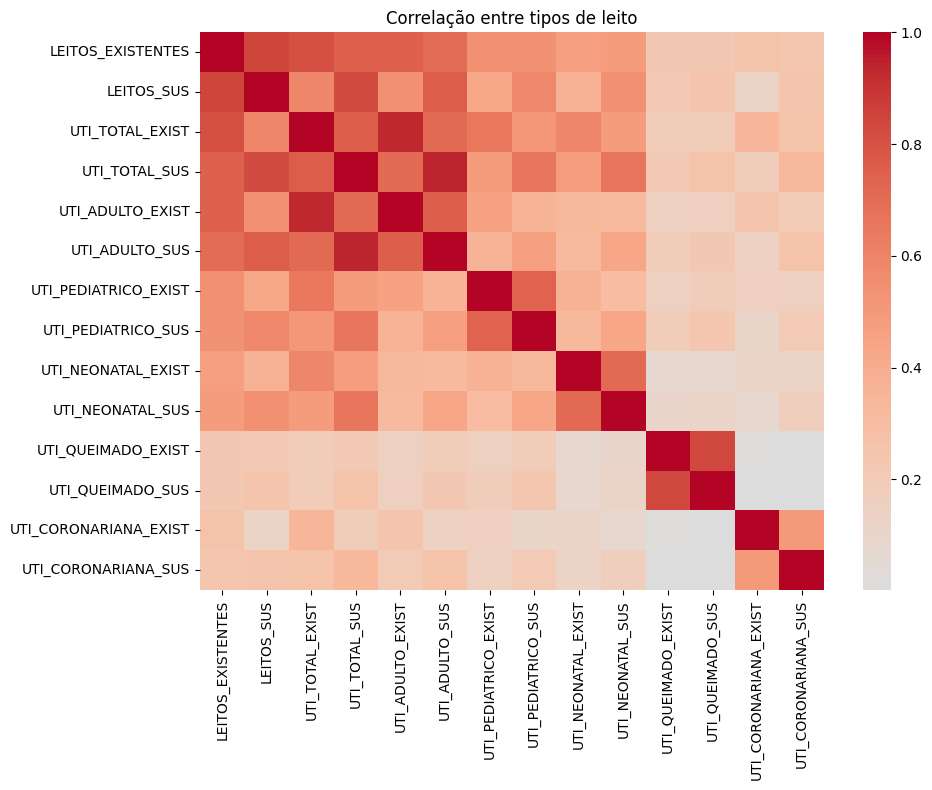

PORTE         Grande  Médio  Pequeno
REGIAO                              
CENTRO-OESTE    4648  14402    10548
NORDESTE       12823  43502    29003
NORTE           3835  13466     5884
SUDESTE        25278  41581    15007
SUL             9087  20269     6510


In [10]:


# 1. Distribuição das variáveis-chave (visual, pro item "análise univariada")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_leitos["LEITOS_EXISTENTES"], bins=50, ax=axes[0])
axes[0].set_title("Distribuição de Leitos Existentes (assimetria à direita)")
sns.histplot(np.log1p(df_leitos["LEITOS_EXISTENTES"]), bins=50, ax=axes[1])
axes[1].set_title("Mesma variável após transformação log (aproxima de normal)")
plt.tight_layout()
plt.savefig("data/processed/dist_leitos.png")
plt.show()

# 2. Correlação entre variáveis numéricas (item "relações entre variáveis")
corr = df_leitos[cols_numericas].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlação entre tipos de leito")
plt.tight_layout()
plt.savefig("data/processed/correlacao_leitos.png")
plt.show()

# 3. Porte por região (insight direto pro painel do gestor)
porte_regiao = df_leitos.groupby(["REGIAO", "PORTE"]).size().unstack(fill_value=0)
print(porte_regiao)